---
numbering: false
---

# 2.8: Systems of linear equations

We have described lines and planes using linear equations. What happens when we require a point to satisfy **several equations at once**? Geometrically, we are looking for the intersection of the corresponding lines or planes.

We'll begin with two equations in two variables, then use lines and planes to explore larger systems. Finally, we'll see why engineering problems can require thousands of equations and why we need a way to solve systems without drawing them.

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import sys
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly
BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'

In [2]:
# Labeled plane patches and intersections for Activity 2.
def activity_plane_diagram(key):
    labels = {
        'start-coincident': ['P₁ = P₂'],
        'start-parallel': ['P₁', 'P₂'],
        'start-line': ['P₁', 'P₂'],
        'case-1': ['P₁ = P₂ = P₃'],
        'case-2': ['P₁ = P₂', 'P₃'],
        'case-3': ['P₁ = P₂', 'P₃'],
        'case-4': ['P₁', 'P₂', 'P₃'],
        'case-5': ['P₁', 'P₂', 'P₃'],
        'case-6': ['P₁', 'P₂', 'P₃'],
        'case-7': ['P₁', 'P₂', 'P₃'],
        'case-8': ['P₁', 'P₂', 'P₃'],
    }[key]
    # A patch in x=0, y=0, z=h, or x+y=h, respectively.
    def patch(kind, h=0):
        if kind == 'z':
            return np.array([[-1.6,-1.6,h],[1.6,-1.6,h],[1.6,1.6,h],[-1.6,1.6,h]])
        if kind == 'x':
            return np.array([[h,-1.6,-1.6],[h,1.6,-1.6],[h,1.6,1.6],[h,-1.6,1.6]])
        if kind == 'y':
            return np.array([[-1.6,h,-1.6],[1.6,h,-1.6],[1.6,h,1.6],[-1.6,h,1.6]])
        return np.array([[-1.3,h+1.3,-1.6],[1.3,h-1.3,-1.6],[1.3,h-1.3,1.6],[-1.3,h+1.3,1.6]])
    configs = {
        'start-coincident': [('z',0)],
        'start-parallel': [('z',0),('z',1)],
        'start-line': [('x',0),('y',0)],
        'case-1': [('z',0)],
        'case-2': [('z',0),('z',1)],
        'case-3': [('z',0),('x',0)],
        'case-4': [('z',0),('z',1),('z',2)],
        'case-5': [('z',0),('z',1),('x',0)],
        'case-6': [('x',0),('y',0),('diag',0)],
        'case-7': [('x',0),('y',0),('diag',1)],
        'case-8': [('x',0),('y',0),('z',0)],
    }[key]
    # Repeated planes share one patch, with equality shown in its label.
    colors = [BLUE,PINK] if key in ('case-2','case-3') else [BLUE,ORANGE,PINK]
    # Project onto the page to make oblique sketches like the worksheet.
    # These are 2D incidence diagrams; the worked examples above remain 3D.
    def project(points):
        points=np.asarray(points,dtype=float)
        return np.column_stack([.9*points[:,0]-.7*points[:,1],
                                .25*points[:,0]+.35*points[:,1]+points[:,2]])
    fig=style_plotly(go.Figure(),renderer='png')
    bounds=[]
    for (kind,h),label,color in zip(configs,labels,colors):
        p=patch(kind,h)
        edge=project(np.vstack([p,p[0]]))
        fill={BLUE:'rgba(61,129,246,.22)',ORANGE:'rgba(255,165,0,.22)',PINK:'rgba(216,26,96,.22)'}[color]
        fig.add_trace(go.Scatter(x=edge[:,0],y=edge[:,1],mode='lines',fill='toself',fillcolor=fill,line=dict(color=color,width=2),showlegend=False,hoverinfo='skip'))
        corner=p[1 if kind in ('diag','z') else 2].copy()
        xy=project([corner])[0]
        xy+=np.array([.15,-.18]) if kind=='diag' else np.array([.15,.15])
        fig.add_trace(go.Scatter(x=[xy[0]],y=[xy[1]],mode='text',text=[label],textposition='middle left' if '=' in label else 'middle center',textfont=dict(color=color,size=17,family='Palatino'),showlegend=False,hoverinfo='skip'))
        bounds.extend(edge.tolist());bounds.append(xy.tolist())
    def line(p,q,dashed=False):
        xy=project([p,q])
        fig.add_trace(go.Scatter(x=xy[:,0],y=xy[:,1],mode='lines',line=dict(color='#222222',width=3,dash='dash' if dashed else 'solid'),showlegend=False,hoverinfo='skip'))
    if key in ('start-line','case-6'):
        line((0,0,-1.6),(0,0,1.6))
    if key=='start-line':
        fig.add_trace(go.Scatter(x=[.18],y=[-.7],mode='text',text=['L'],textfont=dict(color='#222222',size=17,family='Palatino'),showlegend=False))
    if key=='case-3':line((0,-1.6,0),(0,1.6,0))
    if key=='case-5':
        for h in (0,1):line((0,-1.6,h),(0,1.6,h),True)
    if key=='case-7':
        for x,y in ((0,0),(0,1),(1,0)):line((x,y,-1.6),(x,y,1.6),True)
    if key=='case-8':
        for direction in np.eye(3):line(-1.6*direction,1.6*direction,True)
        fig.add_trace(go.Scatter(x=[0],y=[0],mode='markers',marker=dict(color='#222222',size=8),showlegend=False))
    bounds=np.array(bounds)
    fig.update_xaxes(visible=False,range=[bounds[:,0].min()-.4,bounds[:,0].max()+.4],constrain='domain')
    fig.update_yaxes(visible=False,range=[bounds[:,1].min()-.4,bounds[:,1].max()+.4],scaleanchor='x',scaleratio=1)
    fig.update_layout(height=280,width=500,margin=dict(l=5,r=5,t=5,b=5),font=dict(family='Palatino',size=16))
    return fig


---

## Linear equations and their solutions

A **linear equation** in the variables $x_1,\ldots,x_n$ has the form

$$a_1x_1+\cdots+a_nx_n=b,$$

where the coefficients $a_1,\ldots,a_n$ and the right-hand side $b$ are fixed numbers. The variables appear only to the first power, and we do not multiply variables together. For example, $2x-3y=5$ is linear, while $x^2+y=5$ and $xy=5$ are not.

:::{note} Definition: System of linear equations
A **system of linear equations**, or **linear system**, is a collection of linear equations in the same variables. A **solution** is a choice of values for those variables that satisfies **every equation simultaneously**. The **solution set** consists of all such choices.
:::

The number of equations need not equal the number of variables. Three equations in $x$ and $y$ still describe points in $\mathbb R^2$; three equations in $x$, $y$, and $z$ describe points in $\mathbb R^3$.

For our geometric examples, each equation has at least one nonzero variable coefficient. Thus, an equation in two variables describes a line, and an equation in three variables describes a plane.

---

## Two equations in two variables

Consider

$$\begin{cases}a_1x+b_1y=c_1,\\a_2x+b_2y=c_2.\end{cases}$$

Each equation describes a line. A solution belongs to **both** lines, so the solution set is their intersection. There are three possibilities.

| Arrangement | Common solution set | Number of solutions |
| :--- | :--- | :--- |
| Two lines intersect at one point | A point | One |
| Two distinct parallel lines | The empty set | None |
| Two coincident lines | The entire line | Infinitely many |

**Coincident** means that the two equations describe the same line, even if the equations look different.

### Example: One solution

Consider the system:

$$\begin{cases}y=0,\\y=x.\end{cases}$$

The first equation forces $y=0$, and the second then forces $x=0$. The only solution is $(0,0)$, where the lines intersect.

### Example: No solutions

$$\begin{cases}y=1,\\y=-1.\end{cases}$$

No point can have both $y=1$ and $y=-1$. These are distinct parallel lines, so their intersection is empty.

### Example: Infinitely many solutions

$$\begin{cases}x-y=0,\\2x-2y=0.\end{cases}$$

The second equation is twice the first, so it adds no new restriction. Both describe $y=x$. The solution set is

$$\left\{\begin{bmatrix}t\\t\end{bmatrix}:t\in\mathbb R\right\}.$$

```{figure} #plot-28-two-lines
:label: fig-28-two-lines
:class: course-caption
:alt: Two lines meet at the origin, two horizontal lines are parallel and distinct, or two diagonal lines coincide.

Two lines can share one point, no points, or every point on a line. In the last panel, the dashed orange line lies on top of the blue line.
```

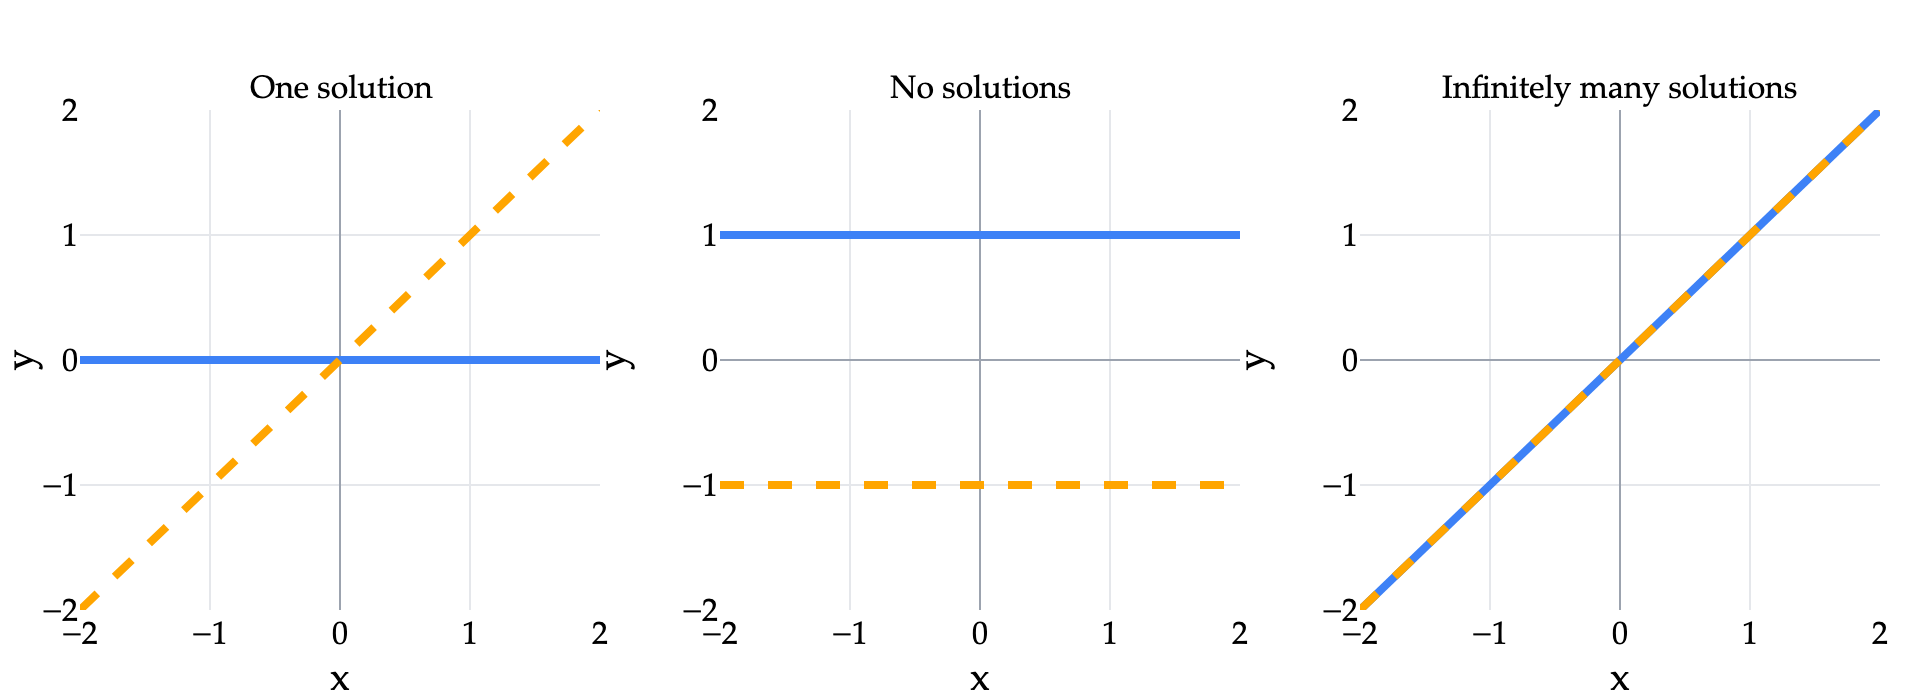

In [3]:
fig=style_plotly(make_subplots(rows=1,cols=3,subplot_titles=['One solution','No solutions','Infinitely many solutions']))
t=np.linspace(-2,2,100)
cases=[[(t,0*t),(t,t)],[(t,0*t+1),(t,0*t-1)],[(t,t),(t,t)]]
for col,lines in enumerate(cases,1):
    for j,(x,y) in enumerate(lines):
        fig.add_trace(go.Scatter(x=x,y=y,mode='lines',line=dict(color=[BLUE,ORANGE][j],width=4,dash='dash' if j else 'solid'),showlegend=False),row=1,col=col)
fig.update_xaxes(range=[-2,2],dtick=1,title_text='x')
fig.update_yaxes(range=[-2,2],dtick=1,title_text='y')
fig.update_layout(width=960,height=350,font=dict(size=16),margin=dict(l=40,r=20,t=55,b=45))
fig.show(renderer='png',scale=2)

---

## More equations and homogeneous systems

Adding an equation means keeping only the points that also satisfy that equation. It can shrink the solution set or leave it unchanged; it can never add new solutions.

For example, $y=0$ and $x=0$ meet at the origin. Adding $x+y=2$ leaves **no** common solution. Each pair of lines intersects, but the three lines do not share a point. A solution of a system must satisfy all of its equations, not just some pair.

:::{note} Definition: Homogeneous system
A linear system is **homogeneous** if every right-hand side is zero when each equation is written as a linear combination of the variables equal to a constant.

For example, $y=x$ can be written as $x-y=0$. The system $y=0$, $y=x$, $y=-x$ is homogeneous.
:::

Every homogeneous system has the **zero solution**, obtained by setting all variables to zero. Geometrically, all its lines or planes pass through the origin. A homogeneous system can therefore never have an empty solution set.

The converse needs care: a system can have solutions without being homogeneous. For instance, $x=1$, $y=2$ has the solution $(1,2)$, but it is not homogeneous in these coordinates.

::::{tip} Activity 1: Three equations in two variables
For each picture below, write three linear equations in $x$ and $y$ with the same arrangement, listing $L_1,L_2,L_3$ in that order. The exact slopes and spacing need not match.

1. Describe the points that satisfy all three equations.
2. Decide which pictures could represent a homogeneous system. No coordinate axes are shown, so you may choose where to place the origin.

Each equation must describe a genuine line: at least one coefficient of $x$ or $y$ must be nonzero. Equations such as $0=0$ and $0=5$ are not allowed here.

```{figure} #plot-28-activity-lines
:label: fig-28-activity-lines
:class: course-caption
:alt: Seven arrangements A through G: three concurrent lines, a triangle, two parallel lines and a transversal, three parallel lines, two coincident lines and a transversal, two coincident lines and a distinct parallel line, and three coincident lines.

Configurations A–G. Labels with an equals sign indicate coincident lines.
```

:::{tip} Solution
:class: dropdown

One choice of equations for each picture is below. The equations in each row are listed in the order $L_1,L_2,L_3$.

| Case | Equations | Common solution set |
| :--- | :--- | :--- |
| A | $y=0$; $y=x$; $y=-x$ | The point $(0,0)$ |
| B | $y=0$; $x=0$; $x+y=2$ | Empty |
| C | $y=1$; $y=-1$; $y=x$ | Empty |
| D | $y=1$; $y=0$; $y=-1$ | Empty |
| E | $y=0$; $2y=0$; $y=x$ | The point $(0,0)$ |
| F | $y=1$; $2y=2$; $y=-1$ | Empty |
| G | $x-y=0$; $2x-2y=0$; $3x-3y=0$ | The line $y=x$ |

**A, E, and G** can represent homogeneous systems. Place the origin at the common intersection in A and E, or anywhere on the common line in G. The other configurations have no common point, so no choice of origin can put it on every line.

To see why there are seven cases, count distinct lines. One distinct line gives G. Two distinct lines either intersect (E) or are parallel (F). With three distinct lines, they are all parallel (D), exactly two are parallel (C), all three meet at one point (A), or their pairwise intersections form a triangle (B).
:::
::::

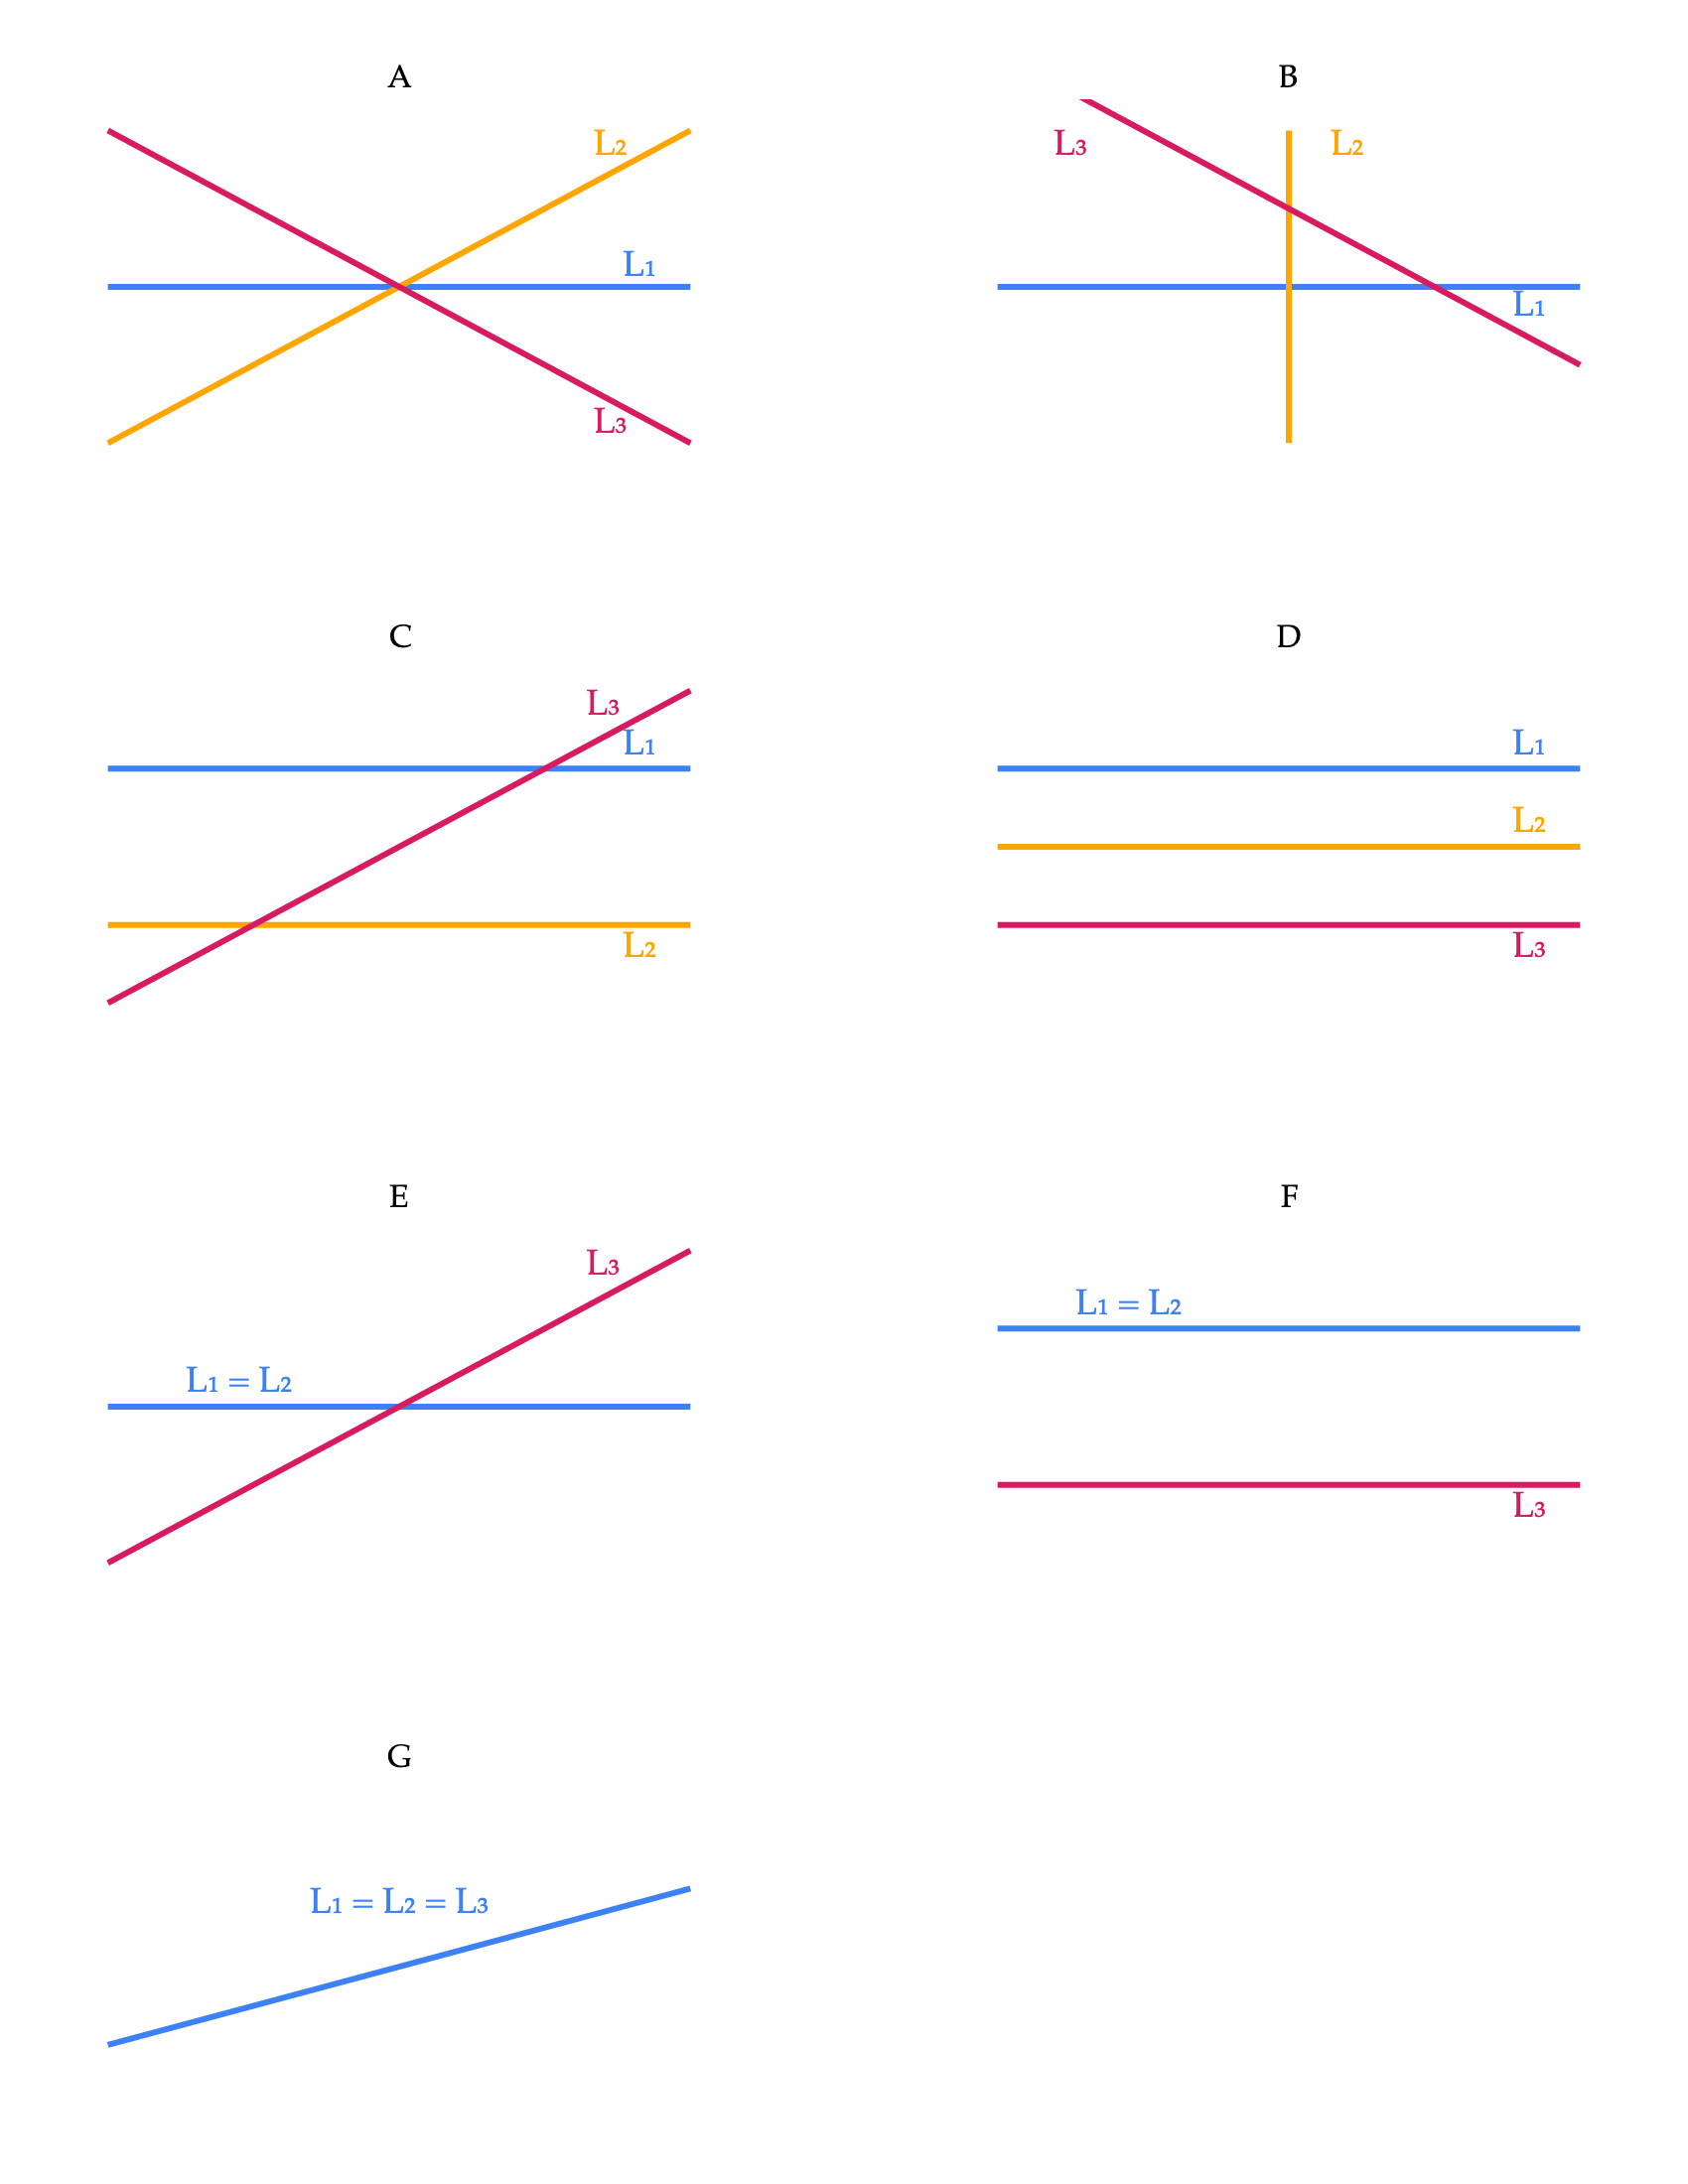

In [4]:
fig=style_plotly(make_subplots(rows=4,cols=2,subplot_titles=list('ABCDEFG')+[''],vertical_spacing=.09,horizontal_spacing=.12))
t=np.linspace(-2,2,100)
configs=[[(t,0*t),(t,t),(t,-t)],[(t,0*t),(0*t,t),(t,1-t)],[(t,0*t+1),(t,0*t-1),(t,t)],[(t,0*t+1),(t,0*t),(t,0*t-1)],[(t,0*t),(t,t)],[(t,0*t+1),(t,0*t-1)],[(t,.5*t)]]
labels=[['L₁','L₂','L₃']]*4+[['L₁ = L₂','L₃'],['L₁ = L₂','L₃'],['L₁ = L₂ = L₃']]
positions=[[(1.65,.25),(1.45,1.8),(1.45,-1.75)],[(1.65,-.25),(.4,1.8),(-1.5,1.8)],[(1.65,1.3),(1.65,-1.3),(1.4,1.8)],[(1.65,1.3),(1.65,.3),(1.65,-1.3)],[(-1.1,.3),(1.4,1.8)],[(-1.1,1.3),(1.65,-1.3)],[(0,.8)]]
for k,lines in enumerate(configs):
    row,col=k//2+1,k%2+1
    for j,((x,y),label,(lx,ly)) in enumerate(zip(lines,labels[k],positions[k])):
        color=[BLUE,ORANGE,PINK][j if k<4 else (0 if j==0 else 2)]
        fig.add_trace(go.Scatter(x=x,y=y,mode='lines',line=dict(color=color,width=3),showlegend=False),row=row,col=col)
        fig.add_trace(go.Scatter(x=[lx],y=[ly],mode='text',text=[label],textfont=dict(color=color,size=18),showlegend=False),row=row,col=col)
fig.update_xaxes(range=[-2.4,2.4],visible=False)
fig.update_yaxes(range=[-2.4,2.4],visible=False)
fig.update_layout(width=850,height=1100,margin=dict(l=25,r=25,t=50,b=15),font=dict(size=18))
fig.show(renderer='png',scale=2)

---

## Three equations in three variables

In $\mathbb R^3$, each equation $ax+by+cz=d$ describes a plane when its normal vector is nonzero. A solution of a three-equation system is a point that lies on **all three planes**.

Two distinct, nonparallel planes meet in a line. A third plane can contain that whole line, meet it at one point, or miss it entirely. The next examples show all three outcomes.

### Example: Three planes sharing a line

Consider

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x-4y+7z=-12.
\end{cases}$$

The first two planes have normals $\begin{bmatrix}2\\-1\\3\end{bmatrix}$ and $\begin{bmatrix}1\\2\\-1\end{bmatrix}$, which are not multiples. They meet in a line. The point $(1,2,-1)$ lies on both planes, and $\begin{bmatrix}-1\\1\\1\end{bmatrix}$ is perpendicular to both normals. Thus, their intersection is

$$\begin{bmatrix}x\\y\\z\end{bmatrix}
=\begin{bmatrix}1\\2\\-1\end{bmatrix}
+t\begin{bmatrix}-1\\1\\1\end{bmatrix},\qquad t\in\mathbb R.$$

The third equation is twice the first minus the second, including the right-hand side:

$$2(-3)-6=-12.$$

Every point on that line therefore satisfies the third equation too. The solution set is the entire line, so there are infinitely many solutions.

### Example: Every pair intersects, but there is no common solution

Change just the last right-hand side:

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x-4y+7z=-11.
\end{cases}$$

Any solution of the first two equations must satisfy $3x-4y+7z=-12$, so it cannot also satisfy the third. There are **no solutions**, even though every pair of planes intersects. Their pairwise intersection lines are distinct and parallel.

### Example: Exactly one solution

Instead, replace the third equation by $3x+y-2z=7$:

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x+y-2z=7.
\end{cases}$$

Every solution must lie on the line from the first example, so substitute $x=1-t$, $y=2+t$, and $z=-1+t$ into the third equation:

$$3(1-t)+(2+t)-2(-1+t)=7,$$

or $7-4t=7$. This forces $t=0$, giving the unique solution $(1,2,-1)$.

```{figure} #plot-28-planes
:label: fig-28-planes
:class: course-caption
:alt: Interactive view of three planes, with a selector for a common line, no common point, or one common point.

Choose one of the three examples, then drag to rotate the planes. The dark line is the intersection of the first two planes; a dark point marks the unique solution in the last example. The colored patches show only part of each infinite plane.
```

In [5]:
fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
# Draw a complete square patch in each plane's own coordinates.
# Using an x-y grid can produce very tall patches for steep planes.
center=np.array([1.,2.,-1.])
a=np.linspace(-3.5,3.5,25)
U,V=np.meshgrid(a,a)
examples=[((3,-4,7),-12),((3,-4,7),-11),((3,1,-2),7)]
patches=[]
for k,(third,d) in enumerate(examples):
    for (normal,rhs,color,name) in [((2,-1,3),-3,BLUE,'Plane 1'),((1,2,-1),6,ORANGE,'Plane 2'),(third,d,PINK,'Plane 3')]:
        normal=np.asarray(normal,dtype=float)
        unit=normal/np.linalg.norm(normal)
        reference=np.eye(3)[np.argmin(np.abs(unit))]
        u=np.cross(unit,reference)
        u/=np.linalg.norm(u)
        v=np.cross(unit,u)
        plane_center=center+(rhs-normal@center)/(normal@normal)*normal
        patch=plane_center[:,None,None]+u[:,None,None]*U+v[:,None,None]*V
        patches.append(patch)
        fig.add_trace(go.Surface(x=patch[0],y=patch[1],z=patch[2],colorscale=[[0,color],[1,color]],showscale=False,opacity=.45,name=name,showlegend=True,visible=k==0,hoverinfo='skip'))
    t=np.linspace(-2,2,80)
    fig.add_trace(go.Scatter3d(x=1-t,y=2+t,z=-1+t,mode='lines',line=dict(color='#222222',width=6),name='First two planes intersect',visible=k==0))
    fig.add_trace(go.Scatter3d(x=[1] if k==2 else [],y=[2] if k==2 else [],z=[-1] if k==2 else [],mode='markers',marker=dict(color='#222222',size=6),name='Unique solution',showlegend=k==2,visible=k==0))
buttons=[dict(label=label,method='update',args=[dict(visible=[j//5==k for j in range(15)])]) for k,label in enumerate(['Common line','No common point','One common point'])]
fig.update_layout(height=560,font=dict(family='Palatino',size=15),margin=dict(l=0,r=0,t=55,b=0),legend=dict(orientation='h',y=-.04),updatemenus=[dict(buttons=buttons,direction='down',x=0,y=1.13)],scene=dict(bgcolor='white',aspectmode='cube',camera=dict(eye=dict(x=1.6,y=-1.8,z=1.2))))
# Keep the same equally scaled bounds for every example, with room around
# every surface vertex so changing examples never clips a plane patch.
points=np.concatenate([patch.reshape(3,-1) for patch in patches],axis=1)
half_width=float(np.max(np.abs(points-center[:,None])))+0.75
axis=dict(backgroundcolor='white',gridcolor='#e5e7eb',showbackground=True)
fig.update_scenes(**{name+'axis':dict(title=name,range=[center[i]-half_width,center[i]+half_width],**axis) for i,name in enumerate(['x','y','z'])})
fig.show()

::::{tip} Activity 2: Three planes in three-dimensional space
Classify all possible configurations of three planes in $\mathbb R^3$. Planes may be parallel, intersect, or coincide. For each configuration:

1. Draw and label $P_1,P_2,P_3$, including any that coincide.
2. Show where each pair intersects, if they intersect.
3. Describe the intersection of all three planes. Does the system have no solutions, one solution, or infinitely many?
4. Write three linear equations with numerical coefficients that produce the configuration. Each equation must have at least one nonzero coefficient of $x$, $y$, or $z$.

Changing angles, spacing, orientation, or plane names does not give a new case. **Hint:** there are eight configurations under these conventions.

Which configurations could represent a homogeneous system? You may choose where to place the origin. If every pair of planes intersects, must all three share a point? Explain how you know your list is complete.

:::{tip} Solution
:class: dropdown

There are eight possible arrangements of three planes. How can we find them all without guessing? **Start with two planes, then add the third.**

### First, consider two planes

Imagine two sheets of paper extending forever in every direction. There are three possibilities:

The planes **coincide**: they are the same plane.

```{figure} #plot-28-start-coincident
:label: fig-28-start-coincident
:class: course-caption
:alt: Two coincident planes share an entire plane.

Two coincident planes share an entire plane. Colored patches represent portions of infinite planes.
```


The planes are **parallel and distinct**: they never meet.

```{figure} #plot-28-start-parallel
:label: fig-28-start-parallel
:class: course-caption
:alt: Two distinct parallel planes have no common points.

Two distinct parallel planes have no common points. Colored patches represent portions of infinite planes.
```


The planes **intersect in a line**.

```{figure} #plot-28-start-line
:label: fig-28-start-line
:class: course-caption
:alt: Two distinct nonparallel planes share the dark line L.

Two distinct nonparallel planes share the dark line L. Colored patches represent portions of infinite planes.
```



Two distinct planes cannot meet at just one point. If two sheets of paper cross, their intersection extends along a line.

Now call our three planes $P_1$, $P_2$, and $P_3$. We will use these three starting possibilities to organize the discussion. Changing the names of the planes does not give a new arrangement, so we will handle repeated planes first, then parallel pairs, then the remaining cases.

### Two planes coincide: three possibilities

Suppose $P_1$ and $P_2$ are the same plane. Requiring a point to lie on both adds no restriction beyond requiring it to lie on that one plane. Adding $P_3$ is therefore just another two-plane problem:

**Case 1: All three planes coincide.** Every point on the shared plane satisfies all three equations. The solution set is a plane, so there are infinitely many solutions.

```{figure} #plot-28-case-1
:label: fig-28-case-1
:class: course-caption
:alt: Case 1: All three planes coincide; the common intersection is the whole plane.

Case 1: All three planes coincide; the common intersection is the whole plane. Colored patches represent portions of infinite planes.
```


**Case 2: The third plane is parallel to the shared plane and distinct from it.** There is no point on both, so the system has no solutions.

```{figure} #plot-28-case-2
:label: fig-28-case-2
:class: course-caption
:alt: Case 2: Two planes coincide and the third is parallel and distinct; there is no common point.

Case 2: Two planes coincide and the third is parallel and distinct; there is no common point. Colored patches represent portions of infinite planes.
```


**Case 3: The third plane intersects the shared plane.** Their intersection is a line. Every point on that line lies on all three planes, so there are infinitely many solutions.

```{figure} #plot-28-case-3
:label: fig-28-case-3
:class: course-caption
:alt: Case 3: Two planes coincide and the third cuts them along the dark common line.

Case 3: Two planes coincide and the third cuts them along the dark common line. Colored patches represent portions of infinite planes.
```



For example, start with $P_1:z=0$ and $P_2:2z=0$. Choosing $P_3$ to be $3z=0$, $z=1$, or $x=0$ produces these three possibilities, respectively.

### Two distinct planes are parallel: two new possibilities

Now suppose all three planes are distinct, and two of them are parallel. Name that pair $P_1$ and $P_2$. We have already handled any arrangement with repeated planes, so $P_3$ cannot coincide with either one.

**Case 4: The third plane is parallel to both.** We have three distinct parallel planes, like three separate sheets of paper stacked above one another.

```{figure} #plot-28-case-4
:label: fig-28-case-4
:class: course-caption
:alt: Case 4: Three distinct parallel planes have no common point.

Case 4: Three distinct parallel planes have no common point. Colored patches represent portions of infinite planes.
```


**Case 5: The third plane cuts both.** It meets $P_1$ along one line and $P_2$ along another. These two lines are distinct and parallel within $P_3$.

```{figure} #plot-28-case-5
:label: fig-28-case-5
:class: course-caption
:alt: Case 5: The third plane cuts a parallel pair along two different dashed lines; no point lies on all three planes.

Case 5: The third plane cuts a parallel pair along two different dashed lines; no point lies on all three planes. Colored patches represent portions of infinite planes.
```



For example, start with $P_1:z=0$ and $P_2:z=1$. Choosing $P_3:z=2$ gives the first arrangement; choosing $P_3:x=0$ gives the second. A plane that cuts one of two parallel planes must cut the other, since the original planes have the same normal direction.

**Both arrangements have no solutions.** There is no point on both $P_1$ and $P_2$, so adding a third plane cannot create a point shared by all three. In particular, the two intersection lines in the second arrangement are pairwise intersections, not solutions of the whole system.

We have now found five arrangements. There are three left.

### Two planes intersect in a line: three remaining possibilities

For the remaining arrangements, all three planes are distinct and no two are parallel. The first two planes meet along a line; call it $L$.

Every solution must already lie on $L$. Thus, instead of trying to picture three planes at once, ask: **How can the line $L$ meet the third plane?**

**Case 6: The entire line lies on $P_3$.** Think of three pages of a book meeting along its spine. All three planes share the same line, so there are infinitely many solutions. For example, $x=0$, $y=0$, and $x+y=0$ all contain the $z$-axis.

```{figure} #plot-28-case-6
:label: fig-28-case-6
:class: course-caption
:alt: Case 6: Three distinct planes meet along the same dark line, like pages meeting along a book spine.

Case 6: Three distinct planes meet along the same dark line, like pages meeting along a book spine. Colored patches represent portions of infinite planes.
```


**Case 8: The line crosses $P_3$ at one point.** That point is the only point on all three planes, so the system has exactly one solution. For example, the $xy$-plane and the $yz$-plane meet along the $y$-axis. The $xz$-plane meets that axis only at the origin. Thus, the three coordinate planes share just the origin.

```{figure} #plot-28-case-8
:label: fig-28-case-8
:class: course-caption
:alt: Case 8: The coordinate planes meet at the dark point; the dashed lines are their pairwise intersections.

Case 8: The coordinate planes meet at the dark point; the dashed lines are their pairwise intersections. Colored patches represent portions of infinite planes.
```


**Case 7: The line is parallel to $P_3$ and does not lie on it.** No point on $L$ belongs to $P_3$, so the system has no solutions. For example, $x=0$ and $y=0$ meet along the $z$-axis, but no point on that axis satisfies $x+y=1$. Each pair of planes still intersects in a line, yet **there is no point shared by all three**.

```{figure} #plot-28-case-7
:label: fig-28-case-7
:class: course-caption
:alt: Case 7: Every pair intersects along a different dashed line, but no point lies on all three planes.

Case 7: Every pair intersects along a different dashed line, but no point lies on all three planes. Colored patches represent portions of infinite planes.
```



These are the only ways a line and a plane can meet. We have therefore found all **$3+2+3=8$ arrangements**, without counting any arrangement twice. The common solution set can be a plane, a line, a single point, or empty.

### Summary of the eight configurations

In each row, the equations are listed in the order $P_1,P_2,P_3$.

| Case | Configuration | Equations | Common intersection |
| :--- | :--- | :--- | :--- |
| 1 | All three coincide | $z=0$; $2z=0$; $3z=0$ | The plane $z=0$; infinitely many solutions |
| 2 | Two coincide; the third is parallel and distinct | $z=0$; $2z=0$; $z=1$ | Empty |
| 3 | Two coincide; the third intersects them | $z=0$; $2z=0$; $x=0$ | The $y$-axis; infinitely many solutions |
| 4 | Three distinct parallel planes | $z=0$; $z=1$; $z=2$ | Empty |
| 5 | Exactly two are parallel; the third cuts both | $z=0$; $z=1$; $x=0$ | Empty |
| 6 | Three distinct planes share a line | $x=0$; $y=0$; $x+y=0$ | The $z$-axis; infinitely many solutions |
| 7 | Every pair intersects, but all three have no common point | $x=0$; $y=0$; $x+y=1$ | Empty |
| 8 | Three planes meet at exactly one point | $x=0$; $y=0$; $z=0$ | The origin; one solution |

For the **pairwise intersections**: coincident planes intersect in the entire plane, and distinct parallel planes have empty intersection. In case 3, the third plane meets each of the coincident planes in the same line. In case 5, the third plane meets the parallel pair in two distinct parallel lines. In case 6, all three pairwise intersections are the same line. In case 7, they are the three parallel lines

$$\begin{bmatrix}0\\0\\t\end{bmatrix},\qquad
\begin{bmatrix}0\\1\\t\end{bmatrix},\qquad
\begin{bmatrix}1\\0\\t\end{bmatrix},\qquad t\in\mathbb R.$$

In case 8, they are the three coordinate axes, which meet at the origin.

**Cases 1, 3, 6, and 8** can represent homogeneous systems. They have a common point where we can place the origin; the numerical examples above are already homogeneous. The remaining configurations have no common point.

**Completeness:** if two planes coincide, we obtain cases 1–3. If all three are distinct and there is a parallel pair, we obtain cases 4–5. Otherwise, $P_1$ and $P_2$ meet along a line $L$. The third plane contains $L$ (case 6), crosses it at one point (case 8), or misses it (case 7). These branches give $3+2+3=8$ arrangements.

Case 7 also answers the discussion question: **pairwise intersection does not guarantee a common solution**.
:::
::::

:::{tip} Possible numbers of solutions
A linear system over the real numbers has **no solutions, exactly one solution, or infinitely many solutions**. It cannot have exactly two solutions.

To see why, suppose $\vec p$ and $\vec q$ are distinct solutions. For any real $t$, the point $\vec p+t(\vec q-\vec p)$ also satisfies every equation: if one equation is $\vec a\cdot\vec x=b$, then

$$\vec a\cdot\bigl(\vec p+t(\vec q-\vec p)\bigr)=b+t(b-b)=b.$$

Thus the entire line through $\vec p$ and $\vec q$ consists of solutions.
:::

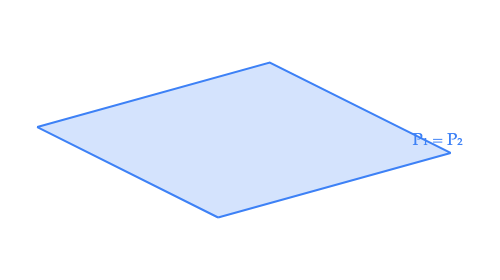

In [6]:
activity_plane_diagram('start-coincident').show()


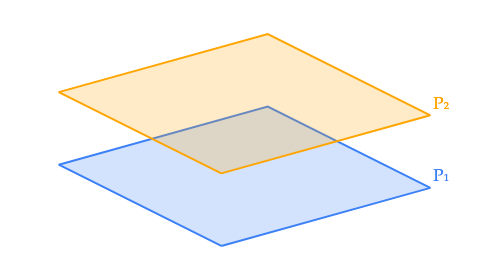

In [7]:
activity_plane_diagram('start-parallel').show()


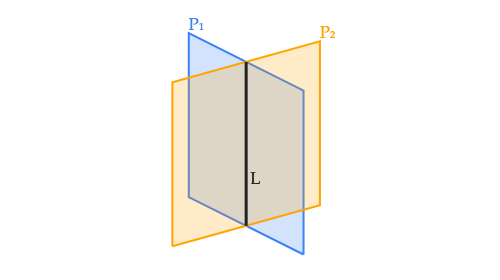

In [8]:
activity_plane_diagram('start-line').show()


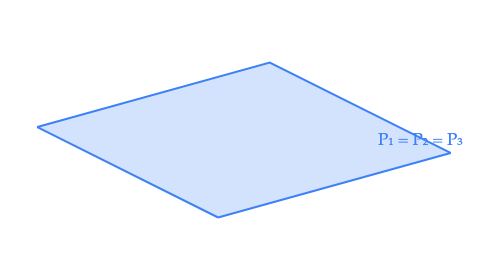

In [9]:
activity_plane_diagram('case-1').show()


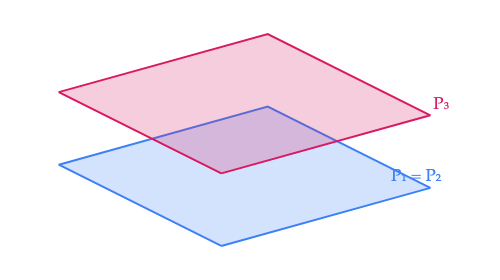

In [10]:
activity_plane_diagram('case-2').show()


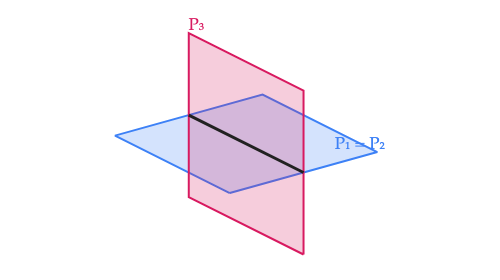

In [11]:
activity_plane_diagram('case-3').show()


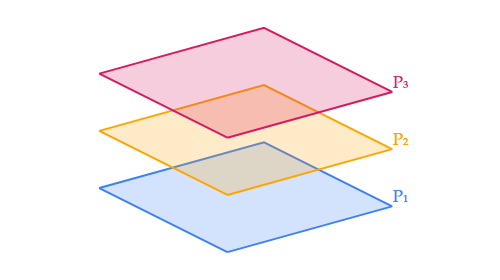

In [12]:
activity_plane_diagram('case-4').show()


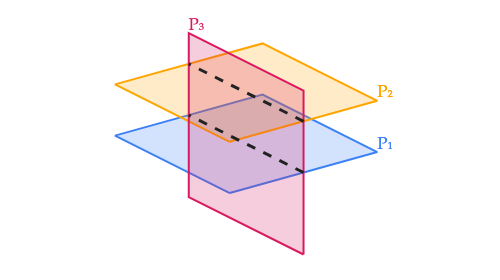

In [13]:
activity_plane_diagram('case-5').show()


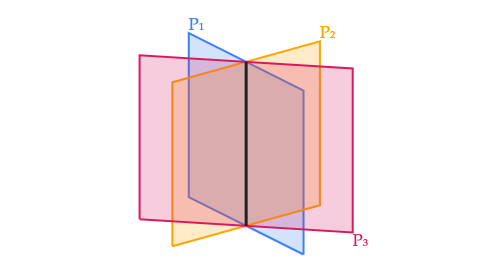

In [14]:
activity_plane_diagram('case-6').show()


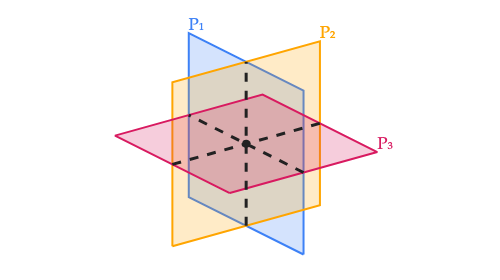

In [15]:
activity_plane_diagram('case-8').show()


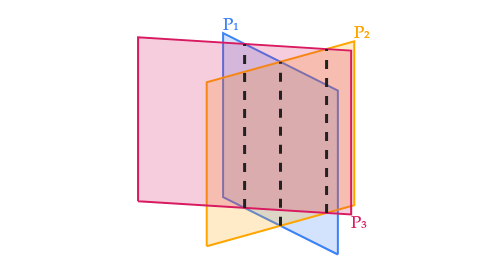

In [16]:
activity_plane_diagram('case-7').show()


---

## Why engineering problems have so many unknowns

The same idea of satisfying several constraints at once appears in heat flow, circuits, and structures. The main difference is the number of variables.

### Temperatures inside a chip

Suppose we model a chip using nine interior grid points. The temperatures along the boundary are known, while the interior temperatures $T_1,\ldots,T_9$ are unknown. The table shows their positions; the boundary values are illustrative temperatures in degrees Celsius after temperatures have settled.

| | | | | |
| :---: | :---: | :---: | :---: | :---: |
| | $40$ | $45$ | $50$ | |
| $35$ | $T_1$ | $T_2$ | $T_3$ | $55$ |
| $40$ | $T_4$ | $T_5$ | $T_6$ | $60$ |
| $45$ | $T_7$ | $T_8$ | $T_9$ | $65$ |
| | $45$ | $50$ | $55$ | |

In this simplified model, heat leaving each interior region balances the heat generated there. The resulting equation says that four times its temperature equals the sum of its four neighboring temperatures plus a source term of $8$.

The neighbors of $T_1$ have temperatures $40$, $35$, $T_2$, and $T_4$, so

$$4T_1=40+35+T_2+T_4+8,$$

or

$$4T_1-T_2-T_4=83.$$

The $8$ is the heat-generation contribution after the model's constants have been combined; it is not a fifth neighboring temperature. Applying the same balance at every interior grid point gives

$$\begin{aligned}
4T_1-T_2-T_4&=83,\\
4T_2-T_1-T_3-T_5&=53,\\
4T_3-T_2-T_6&=113,\\
4T_4-T_1-T_5-T_7&=48,\\
4T_5-T_2-T_4-T_6-T_8&=8,\\
4T_6-T_3-T_5-T_9&=68,\\
4T_7-T_4-T_8&=98,\\
4T_8-T_5-T_7-T_9&=58,\\
4T_9-T_6-T_8&=128.
\end{aligned}$$

There are nine equations in nine unknowns. We need temperatures that satisfy all nine equations simultaneously; changing one temperature affects several balances.

A finer grid estimates temperatures at more locations:

| Interior grid | Unknown temperatures | Linear equations |
| :--- | ---: | ---: |
| $3\times3$ | 9 | 9 |
| $10\times10$ | 100 | 100 |
| $100\times100$ | 10,000 | 10,000 |

### Voltages in a resistor network

Now consider a circuit with six unknown junction voltages $x_1,\ldots,x_6$. A supply holds the left rail at $12$ volts and the right rail at $0$ volts. At every junction, current entering equals current leaving.

At junction $x_1$, a $2\,\Omega$ resistor connects to the $12$-volt rail, a $3\,\Omega$ resistor connects to $x_2$, and a $6\,\Omega$ resistor connects to $x_4$. Ohm's law gives current as voltage difference divided by resistance, so

$$\frac{12-x_1}{2}=\frac{x_1-x_2}{3}+\frac{x_1-x_4}{6}.$$

Multiplying by $6$ and collecting terms gives

$$6x_1-2x_2-x_4=36.$$

Writing the corresponding balance at each junction in the network gives

$$\begin{aligned}
6x_1-2x_2-x_4&=36,\\
-4x_1+13x_2-3x_3-6x_5&=0,\\
-x_2+4x_3-x_6&=0,\\
-2x_1+11x_4-6x_5&=36,\\
-3x_2-3x_4+8x_5-2x_6&=0,\\
-3x_3-4x_5+9x_6&=0.
\end{aligned}$$

Each unknown voltage appears in several equations because neighboring junctions are connected. A network with 5,000 unknown junction voltages similarly gives 5,000 current-balance equations.

### Bridges and aircraft wings

For a structural model, the unknowns can be displacements. A model with 10,000 freely moving points in three-dimensional space has 30,000 unknown displacement components: one in each coordinate direction at each point. For small deformations, a linear model relates these displacements to the applied forces.

---

## Next: Organizing systems using matrices

Geometry tells us what a solution means: it must satisfy every equation at once. It also helps us understand why a system may have no solutions, one solution, or infinitely many.

But we cannot solve a system with thousands of variables by drawing its solution set. We need **algebraic methods** that organize the coefficients and operate on the equations systematically.

Next time, we'll introduce **matrices**, which give us a compact way to organize linear systems and a starting point for methods that work far beyond two or three variables.